# ZINC Non-Streaming Demo

This notebook mirrors the lean streaming demo, but uses the regular in-memory `fit(...)` path.

- source: raw ZINC CSV
- sample limit: `0.1`
- fit mode: materialize sampled graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from pathlib import Path
import random
import warnings

import numpy as np
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

from conditional_node_field_graph_generator.notebooks import configure_notebook, download_zinc_dataset
globals().update(configure_notebook(require_nsppk=True, print_torch=True))
import torch
torch.set_float32_matmul_precision('high')

from abstractgraph_graphicalizer.chem import draw_molecule, draw_molecules
from conditional_node_field_graph_generator.input_sources import iter_selected_source_graphs
from conditional_node_field_graph_generator.extensions.demo import show_molecules
from conditional_node_field_graph_generator.extensions.demo.visualization import plot_networkx_graphs
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
ZINC_SIZE = 'zinc'
ZINC_FILENAME = f'{ZINC_SIZE}.csv'
RANDOM_SEED = 42
# zinc.csv has roughly 499k rows. Use 200k for the first larger run;
# set DATA_LIMIT = None to consume the full file.
DATA_LIMIT = None
FIT_BATCH_SIZE = 256
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10

# Fit SVD bases on a fixed row sample, then project the full dataset.
EMBEDDING_DIM = 256
EMBEDDING_SVD_DIM = 64
EMBEDDING_SVD_FIT_MAX_ROWS = 100_000
EMBEDDING_SVD_TRANSFORM_BATCH_SIZE = 10_000
LEARNING_RATE = 1e-4
SPARSE_SUPERVISION_MASK_RATIO = 0.35

# Capacity knobs. The 55k loss curves looked capacity-limited rather than
# overfit, so this larger zinc.csv run uses a wider/deeper transformer while
# keeping the SVD projection at 64 dimensions.
NUMBER_OF_TRANSFORMER_LAYERS = 6
TRANSFORMER_ATTENTION_HEAD_COUNT = 8
TRANSFORMER_DROPOUT = 0.10

# Structural supervision weights.
LAMBDA_DEGREE_IMPORTANCE = 4.0
LAMBDA_NODE_LABEL_IMPORTANCE = 3.0
LAMBDA_EDGE_LABEL_IMPORTANCE = 3.0
LAMBDA_DIRECT_EDGE_IMPORTANCE = 3.0
LAMBDA_AUXILIARY_EDGE_IMPORTANCE = 2.0

DATA_LIMIT_LABEL = 'all' if DATA_LIMIT is None else DATA_LIMIT
MODEL_NAME = (
    f'{ZINC_SIZE}-nonstreaming-d{EMBEDDING_DIM}-svd{EMBEDDING_SVD_DIM}-s{DATA_LIMIT_LABEL}'
    f'-b{FIT_BATCH_SIZE}-lr{LEARNING_RATE:g}-mask{SPARSE_SUPERVISION_MASK_RATIO:g}'
    f'-l{NUMBER_OF_TRANSFORMER_LAYERS}-drop{TRANSFORMER_DROPOUT:g}'
    f'-e{MAXIMUM_EPOCHS}'
)
# Keep preprocessing serial for the non-streaming notebook. The parallel
# vectorizer/feasibility path can wedge in long-lived notebook kernels before
# training starts, leaving no useful progress output.
VECTORIZER_PARALLEL = True
FEASIBILITY_PARALLEL = True
FEASIBILITY_N_JOBS = -1
DECODER_N_JOBS = -1
DECODER_SOLVER_THREADS = 16
MAX_DECODE_SECONDS_PER_SAMPLE = 30.0
MAX_DECODE_ATTEMPTS_PER_SAMPLE = 2


random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [3]:
csv_path = download_zinc_dataset(ZINC_DATA_ROOT, filename=ZINC_FILENAME)
print(f'ZINC CSV: {csv_path}')

graphs = list(
    iter_selected_source_graphs(
        csv_path,
        'zinc_csv',
        limit=DATA_LIMIT,
        random_state=RANDOM_SEED,
    )
)
print(f'Loaded {len(graphs)} graphs into memory for non-streaming fit.')

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    graph_embedding_svd_dimension=EMBEDDING_SVD_DIM,
    embedding_svd_fit_max_rows=EMBEDDING_SVD_FIT_MAX_ROWS,
    embedding_svd_transform_batch_size=EMBEDDING_SVD_TRANSFORM_BATCH_SIZE,
    number_of_transformer_layers=NUMBER_OF_TRANSFORMER_LAYERS,
    transformer_attention_head_count=TRANSFORMER_ATTENTION_HEAD_COUNT,
    transformer_dropout=TRANSFORMER_DROPOUT,
    node_vectorizer_dense=False,
    graph_vectorizer_dense=False,
    node_vectorizer_parallel=VECTORIZER_PARALLEL,
    graph_vectorizer_parallel=VECTORIZER_PARALLEL,
    feasibility_parallel=FEASIBILITY_PARALLEL,
    feasibility_n_jobs=FEASIBILITY_N_JOBS,
    locality_horizon=2,
    sparse_supervision_mask_ratio=SPARSE_SUPERVISION_MASK_RATIO,
    learning_rate=LEARNING_RATE,
    lambda_degree_importance=LAMBDA_DEGREE_IMPORTANCE,
    lambda_node_label_importance=LAMBDA_NODE_LABEL_IMPORTANCE,
    lambda_edge_label_importance=LAMBDA_EDGE_LABEL_IMPORTANCE,
    lambda_direct_edge_importance=LAMBDA_DIRECT_EDGE_IMPORTANCE,
    lambda_auxiliary_edge_importance=LAMBDA_AUXILIARY_EDGE_IMPORTANCE,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    decoder_solver_threads=DECODER_SOLVER_THREADS,
    max_decode_seconds_per_sample=MAX_DECODE_SECONDS_PER_SAMPLE,
    max_decode_attempts_per_sample=MAX_DECODE_ATTEMPTS_PER_SAMPLE,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
print('node_vectorizer_dense =', graph_generator.node_graph_vectorizer.dense)
print('graph_vectorizer_dense =', graph_generator.graph_vectorizer.dense)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
graph_generator.graph_decoder.diagnostic_graph_renderer = draw_molecules
graph_generator.graph_decoder.adjacency_time_limit_seconds = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.graph_decoder.parallel_decode_timeout_seconds = MAX_DECODE_SECONDS_PER_SAMPLE

TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS = {
    'size': (500, 350),
    'cell_size': 2.8,
    'title_font_size': 8,
}
TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


ZINC CSV: /cs0eth/home/fc334/code/NodeField/notebooks/datasets/zinc/zinc.csv
Loaded 249455 graphs into memory for non-streaming fit.
Configured graph generator model_name=zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
node_vectorizer_dense = False
graph_vectorizer_dense = False
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/zinc-nonstreaming-d256-svd64-sall-b256-lr0.0001-mask0.35-l6-drop0.1-e350/training_samples.pdf


Fit target model_name=zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 249455 graphs
Fitting graph vectorizer on 249455 graphs
Finished fitting graph vectorizer on 249455 graphs in 0m 0.0s
Fitting node graph vectorizer on 249455 graphs
Finished fitting node graph vectorizer on 249455 graphs in 0m 0.0s
Encoding node embeddings for 249455 graphs
Finished encoding node embeddings for 249455 graphs in 14m 11.6s
Encoding graph embeddings for 249455 graphs
Finished encoding graph embeddings for 249455 graphs in 12m 18.4s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(5775223, 2048), sparse=True, nnz=1027259554, density=0.086852.
Prepared graph embedding matrix: shape=(249455, 2048), sparse=True, nnz=241862688, density=0.473420.
Sampled node embedding SVD fit rows: 5775223 -> 100000.
Fitting node embedding SVD on shape=(100000, 20

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


epoch 1: completed epoch in 1147.99s
epoch 2: completed epoch in 1148.04s
epoch 3: completed epoch in 1169.17s
epoch 4: completed epoch in 1150.42s
epoch 5: completed epoch in 1426.08s
epoch 6: completed epoch in 1527.43s
epoch 7: completed epoch in 1497.90s
epoch 8: completed epoch in 1459.02s
epoch 9: completed epoch in 1499.55s
Epoch 10/350 | ETA 141h 17m 41s:
  train total=   81.534 | node_field    20.418 [25.0%] |        deg    1.1585 [1.4%] |      exist   0.32252 [0.4%] | node_count   0.01853 [<0.1%]
  val   total=   79.175 | node_field    20.231 [25.6%] |        deg    1.0735 [1.4%] |      exist   0.29162 [0.4%] | node_count   0.01573 [<0.1%]
  train                 | node_label   0.31890 [0.4%] | edge_label   0.32445 [0.4%] |       edge    1.6020 [2.0%] | edge_count    56.173 [68.9%] | deg_edge_consistency   0.00006 [<0.1%]
  val                   | node_label   0.28847 [0.4%] | edge_label   0.29371 [0.4%] |       edge    1.5044 [1.9%] | edge_count    54.348 [68.6%] | deg_edge_

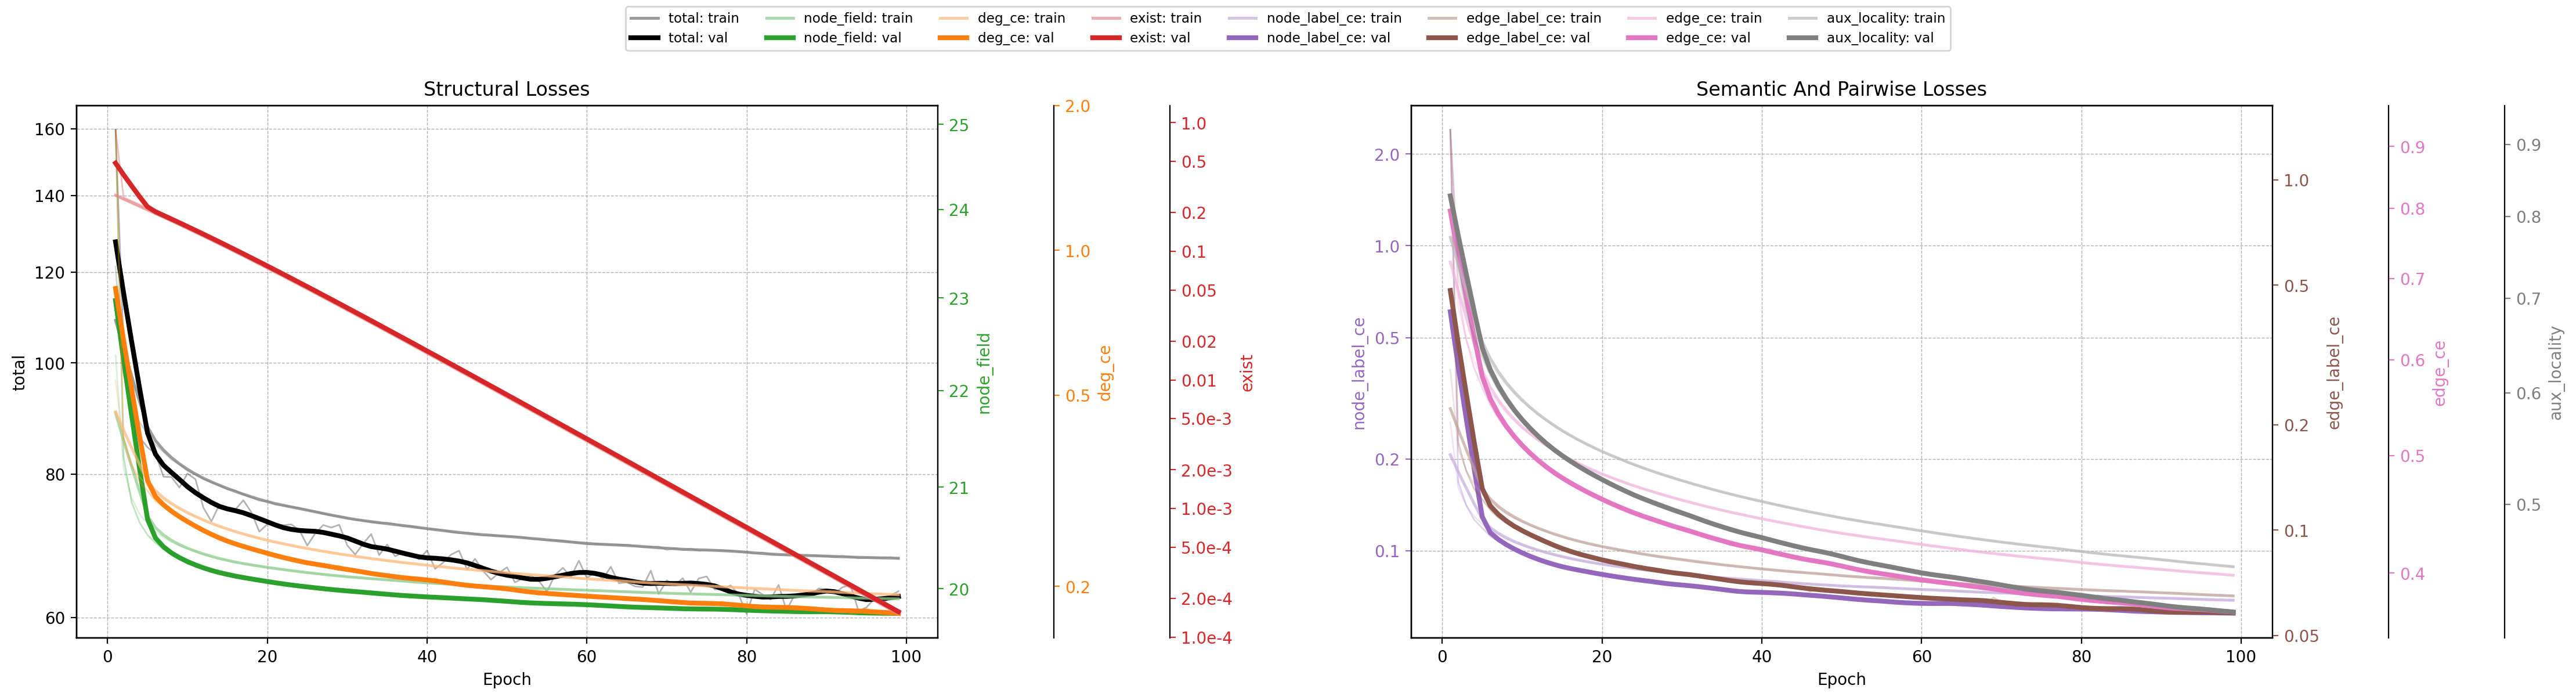

training_graph_conditioning_ = 249455
is_fitted_ = True
CPU times: user 1d 50min 53s, sys: 9h 37min 59s, total: 1d 10h 28min 52s
Wall time: 1d 10h 45min 35s


In [4]:
%%time
graph_generator.fit(
    graphs,
    train_node_generator=True,
    targets=None,
    sample_training_progress=True,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=50,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_kwargs=TRAINING_PROGRESS_MOLECULE_PLOT_KWARGS,
    sample_training_progress_plot_fn=draw_molecule,
)

print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [5]:
#load model
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)
SAVED_GENERATOR_ROOT = REPO_ROOT / '.artifacts' / 'saved_generators'
list_saved_graph_generators(SAVED_GENERATOR_ROOT)
#MODEL_NAME = 'zinc15-nonstreaming-d64-s10000-b128-e350'
graph_generator = load_graph_generator(MODEL_NAME+'.pkl', model_dir=SAVED_GENERATOR_ROOT)
graph_generator.graph_decoder.solver_threads = DECODER_SOLVER_THREADS
graph_generator.max_decode_seconds_per_sample = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.max_decode_attempts_per_sample = MAX_DECODE_ATTEMPTS_PER_SAMPLE
graph_generator.graph_decoder.adjacency_time_limit_seconds = MAX_DECODE_SECONDS_PER_SAMPLE
graph_generator.graph_decoder.parallel_decode_timeout_seconds = MAX_DECODE_SECONDS_PER_SAMPLE


,name,modified,size_mb
0,zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350.pkl,2026-06-13 03:43,161.000000
1,zinc20-nonstreaming-d192-svd64-s55000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-10 21:04,45.100000
2,artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350.pkl,2026-06-10 14:54,20.300000
3,zinc20-nonstreaming-d192-s33000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 23:16,70.500000
4,zinc20-nonstreaming-d192-s5000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 14:53,29.000000
5,zinc20-nonstreaming-d192-s1000-b256-lr0-0001-mask0-35-l4-drop0-15-e350.pkl,2026-06-09 11:22,23.100000
6,artificial-cycle-path-star-n60000-c4-nc2-p2-r2x2-d128-b128-e350.pkl,2026-06-08 13:50,70.900000
7,zinc20-nonstreaming-d128-s50000-b512-lr0-0002-mask0-5-e350.pkl,2026-06-05 20:06,61.000000
8,artificial-cycle-path-star-n6000-c4-nc2-p2-r2x2-d64-b128-e350.pkl,2026-06-05 20:01,8.900000
9,artificial-cycle-path-star-n6000-c4-p2-r2x2-d64-b128-e350.pkl,2026-06-05 17:40,8.900000


Loaded graph generator: zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350.pkl
/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators/zinc-nonstreaming-d256-svd64-sall-b256-lr0-0001-mask0-35-l6-drop0-1-e350.pkl


In [6]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = [graph for graph in sample_variants[variant_key] if graph is not None]
    if not variant_samples:
        print(f'No {title_prefix} samples to display.')
        continue
    show_molecules(
        variant_samples,
        n=len(variant_samples),
        title=f'Non-streaming ZINC {title_prefix} samples',
        legends=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
        n_graphs_per_line=n_samples,
    )


Process-based decode parallelism unavailable; falling back to threads.


RuntimeError: Adjacency ILP did not produce an optimal solution (status=Not Solved, code=0, n=38, target_degree_sum=30, connectivity=True).

Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 1 | feasible_rate= 12.5% | attempt_time=16m 54.2s | eta=    0.0s
Feasibility filtering summary: generated=8, feasible_candidates=1, feasible_rate=12.5%, fulfilled_slots=1/1.
Feasibility attempt  1/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=4m 23.0s | eta=1h 23m 16.7s
Feasibility attempt  2/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=7m 12.9s | eta=1h 44m 23.0s
Feasibility attempt  3/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=8m 51.8s | eta=1h 55m 56.9s
Oracle-guided adjacency solve failed with 19 active cuts at iteration 7/16; retrying with fewer cuts.
Feasibility attempt  4/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=6m 55.9s | eta=1h 49m 34.5s
Feasibility attempt  5/20 | generated=   8 | feasible_candidates= 0 | feasible_rate=  0.0% | attempt_time=9m 08.7s | eta=1

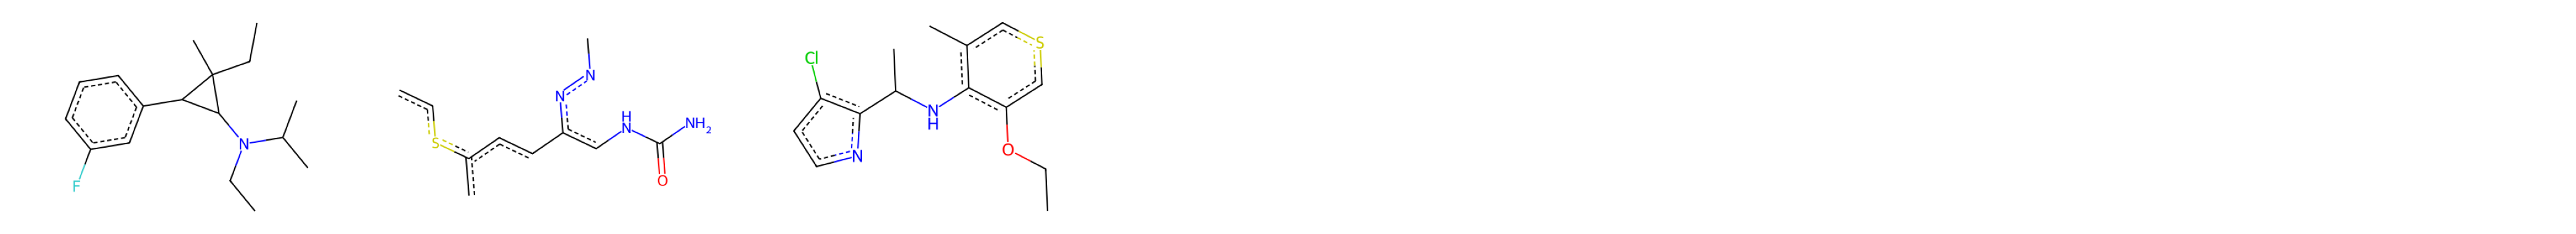

In [ ]:
if graph_generator.feasibility_estimator is None:
    raise RuntimeError('Feasibility estimator is unavailable in this environment.')

filtered_samples = graph_generator.sample(
    n_samples=n_samples,
    apply_feasibility_filtering=True,
)
show_molecules(filtered_samples, n=n_samples, title='Non-streaming ZINC samples with feasibility filtering')
